In [1]:
import os
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow_model_optimization.python.core.keras.compat import keras#一定得是tfmot里的keras

layers = keras.layers
models = keras.models
from IPython import display

# Set the seed value for experiment reproducibility.
DATASET_PATH = 'data/mini_speech_commands/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')

data_dir = pathlib.Path(DATASET_PATH)

In [2]:
print(tf.__version__)  # 应显示 2.x 版本
print(dir(tf.io))     # 应包含 'gfile' 属性

2.20.0
['FixedLenFeature', 'FixedLenSequenceFeature', 'RaggedFeature', 'SparseFeature', 'TFRecordOptions', 'TFRecordWriter', 'VarLenFeature', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_sys', 'decode_and_crop_jpeg', 'decode_base64', 'decode_bmp', 'decode_compressed', 'decode_csv', 'decode_gif', 'decode_image', 'decode_jpeg', 'decode_json_example', 'decode_png', 'decode_proto', 'decode_raw', 'decode_webp', 'deserialize_many_sparse', 'encode_base64', 'encode_jpeg', 'encode_png', 'encode_proto', 'extract_jpeg_shape', 'gfile', 'is_jpeg', 'match_filenames_once', 'matching_files', 'parse_example', 'parse_sequence_example', 'parse_single_example', 'parse_single_sequence_example', 'parse_tensor', 'read_file', 'serialize_many_sparse', 'serialize_sparse', 'serialize_tensor', 'write_file', 'write_graph']


In [3]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands

array(['down', 'go', 'left', 'no', 'README.md', 'right', 'stop', 'up',
       'yes'], dtype='<U9')

In [4]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both'
)
#一批次64张图片（64段语音） 验证集比例20% 采样率16k

label_names = np.array(train_ds.class_names)
print("label names:", label_names)

def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
full_val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

test_ds = full_val_ds.shard(num_shards=2, index=0)
val_ds = full_val_ds.shard(num_shards=2, index=1)
#验证集比例20% 分为新验证集和测试集 1：1 现比例为训练：验证：测试=8：1：1


print(train_ds.element_spec)

for example_audio, example_labels in train_ds.take(1):  
  print(example_audio.shape)
  print(example_labels.shape)
    
print(test_ds.cardinality())
print(train_ds.cardinality())

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.
label names: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']
(TensorSpec(shape=(None, 16000), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
(64, 16000)
(64,)
tf.Tensor(13, shape=(), dtype=int64)
tf.Tensor(100, shape=(), dtype=int64)


In [5]:
label_names[[1,7,3,0]]

array(['go', 'yes', 'no', 'down'], dtype='<U5')

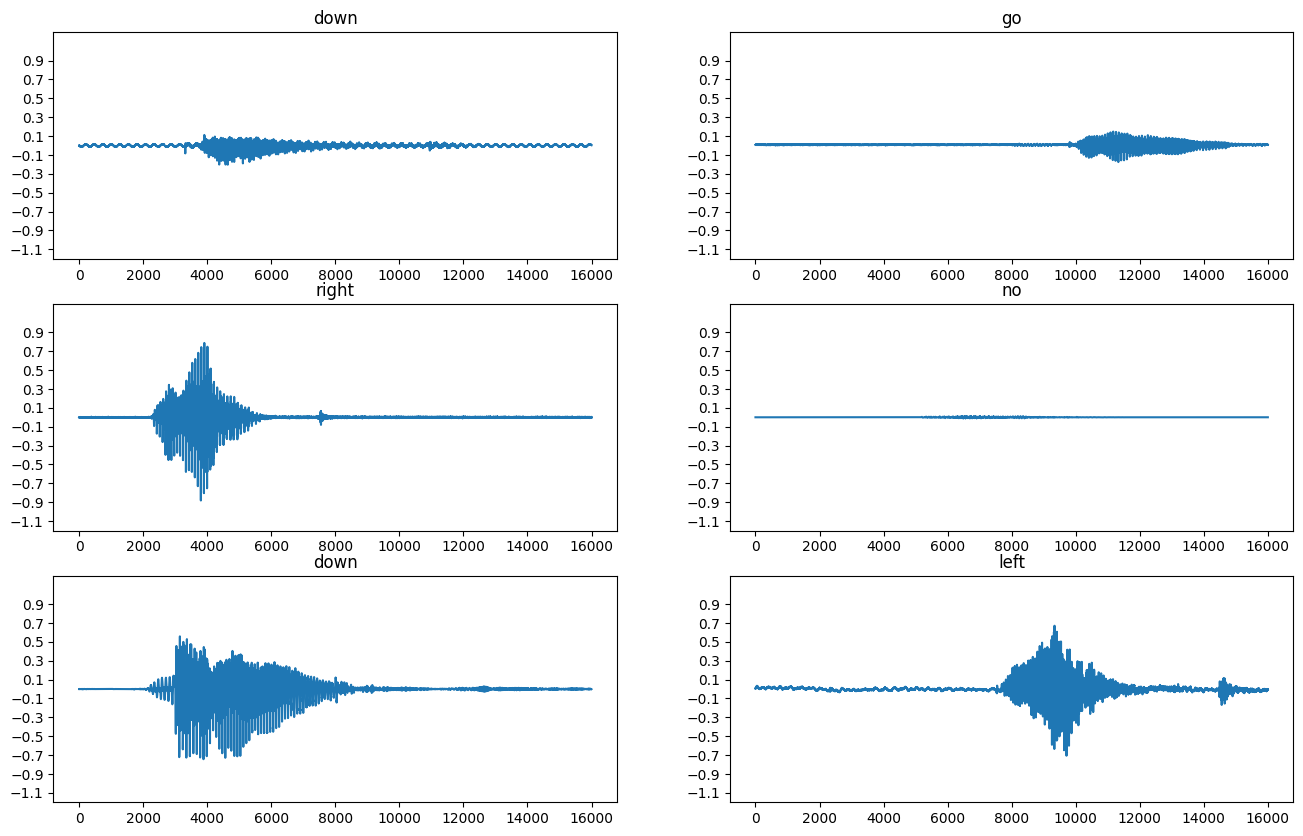

In [6]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 2
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.1, 1.1, 0.2))
  plt.ylim([-1.2, 1.2])
#绘图

In [7]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

#进行stft变化（短时傅里叶变换）得到频谱图（时间-频率）

In [8]:
for i in range(5):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Label: down
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: go
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: right
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: no
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: down
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


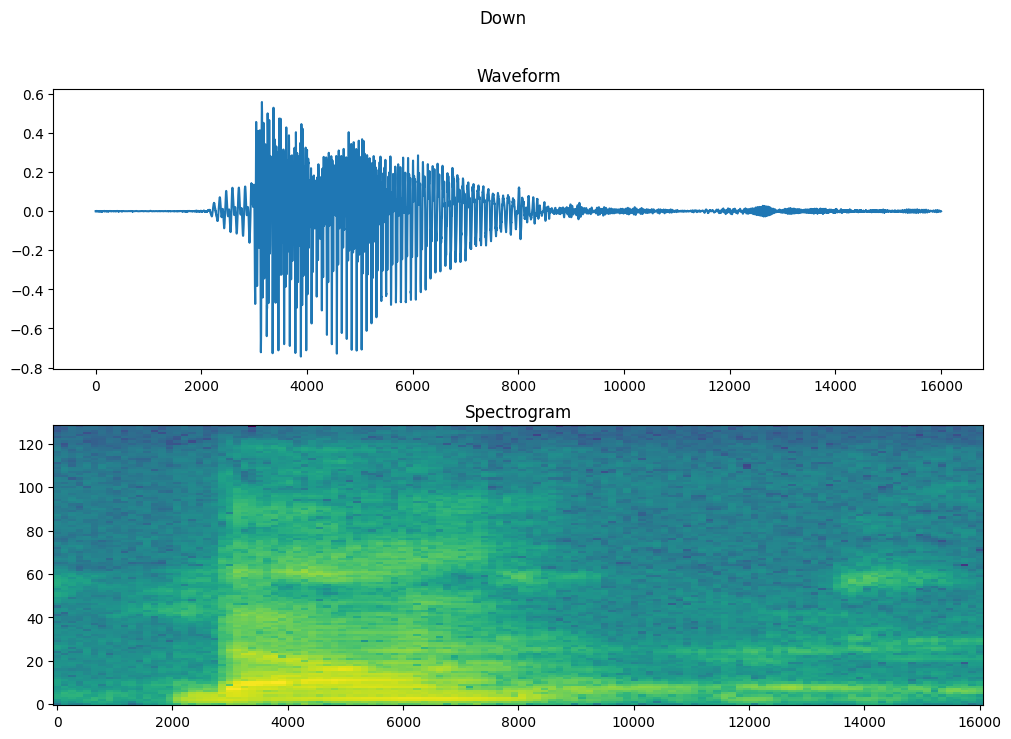

In [9]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)  #给不同频率以不同颜色绘图 得到ai可以识别的图
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [10]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)
#遍历全部的数据 全部转为频谱图

In [11]:
test_spectrogram_ds

<_ParallelMapDataset element_spec=(TensorSpec(shape=(None, 124, 129, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

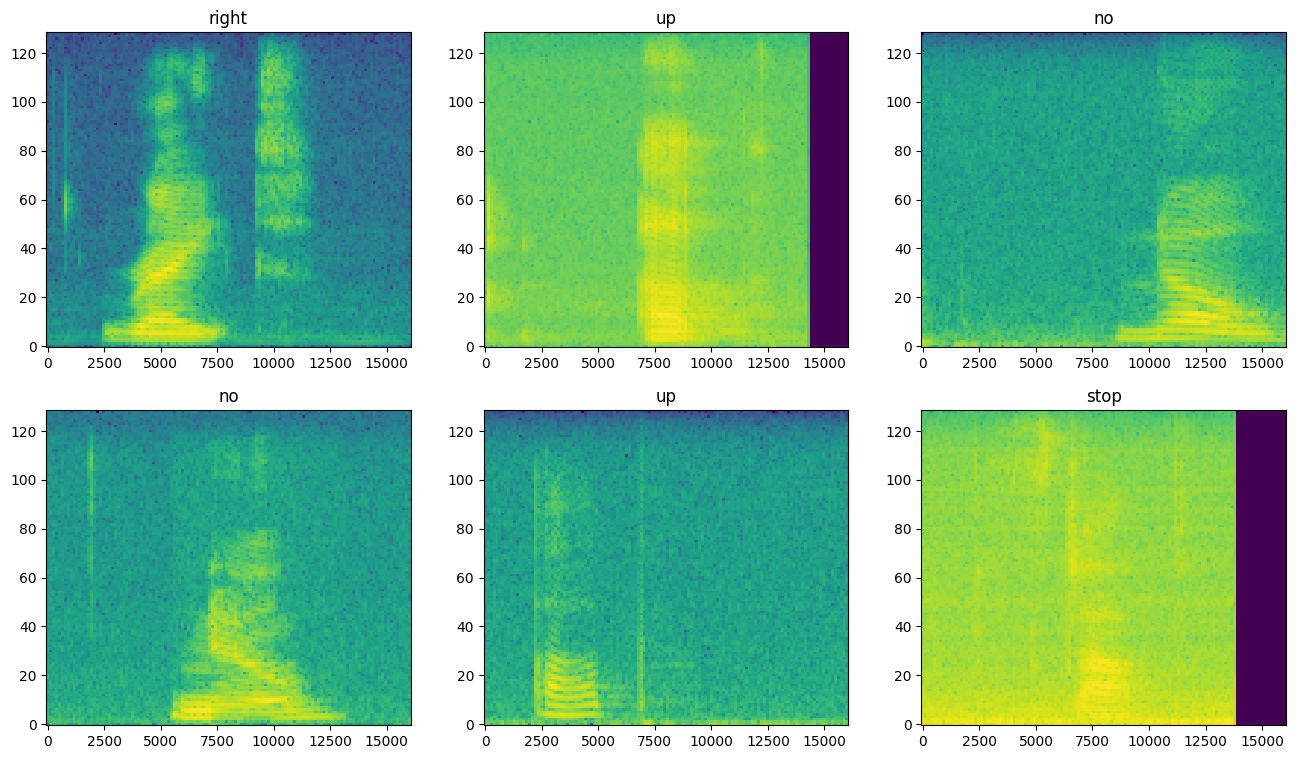

In [12]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break
rows = 2
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

In [13]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

In [14]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)
print('Input shape:', num_labels)


norm_layer = layers.Normalization()
#norm层定义 数据统一层
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

preprocessing_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    norm_layer, 
])

# 构建主模型（将接受32x32的输入）
prunable_model = keras.Sequential([
    layers.Input(shape=(32, 32, input_shape[-1])),
    layers.Conv2D(16, 3, activation='relu'),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

# 组合模型 这样做的目的是剪枝不能处理resizing层 如果将resizing层除去的话 数据量将会过大
input_tensor = layers.Input(shape=input_shape)
x = preprocessing_model(input_tensor)
output_tensor = prunable_model(x)
model = keras.Model(inputs=input_tensor, outputs=output_tensor)

model.summary()#展示模型细节

Input shape: (124, 129, 1)
Input shape: 8


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 124, 129, 1)]     0         
                                                                 
 sequential (Sequential)     (None, 32, 32, 1)         3         
                                                                 
 sequential_1 (Sequential)   (None, 8)                 205800    
                                                                 
Total params: 205803 (803.92 KB)
Trainable params: 205800 (803.91 KB)
Non-trainable params: 3 (16.00 Byte)
_________________________________________________________________


In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)
EPOCHS = 40
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS
)#训练开始 训练40次 损失函数为交叉熵

Epoch 1/40


100/100 [==============================] - 12s 100ms/step - loss: 1.9736 - accuracy: 0.2445 - val_loss: 1.7446 - val_accuracy: 0.4609
Epoch 2/40
100/100 [==============================] - 2s 22ms/step - loss: 1.7070 - accuracy: 0.3567 - val_loss: 1.4779 - val_accuracy: 0.5508
Epoch 3/40
100/100 [==============================] - 2s 22ms/step - loss: 1.5171 - accuracy: 0.4395 - val_loss: 1.2901 - val_accuracy: 0.5807
Epoch 4/40
100/100 [==============================] - 2s 22ms/step - loss: 1.3920 - accuracy: 0.4892 - val_loss: 1.1414 - val_accuracy: 0.6576
Epoch 5/40
100/100 [==============================] - 2s 22ms/step - loss: 1.2625 - accuracy: 0.5275 - val_loss: 1.0005 - val_accuracy: 0.6901
Epoch 6/40
100/100 [==============================] - 2s 22ms/step - loss: 1.1590 - accuracy: 0.5669 - val_loss: 0.9498 - val_accuracy: 0.7396
Epoch 7/40
100/100 [==============================] - 2s 21ms/step - loss: 1.0879 - accuracy: 0.5936 - val_loss: 0.8753 - val_accuracy: 0.

Text(0, 0.5, 'Accuracy [%]')

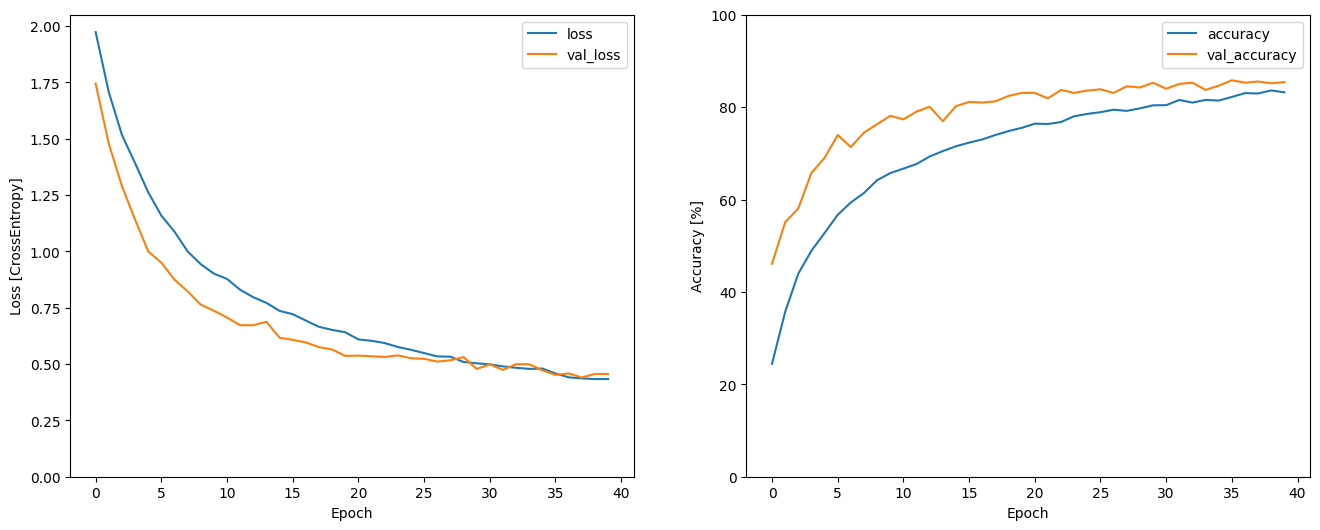

In [16]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')#以损失函数和准确度为基准绘图

In [17]:
_, baseline_model_accuracy = model.evaluate(
    test_spectrogram_ds,  verbose=0)
keras_file = 'pruned_model.keras'  # 使用 .keras 扩展名
keras.models.save_model(model, keras_file)
print('Saved baseline model to:', keras_file) #保存keras模型

Saved baseline model to: pruned_model.keras


13/13 [==============================] - 0s 8ms/step


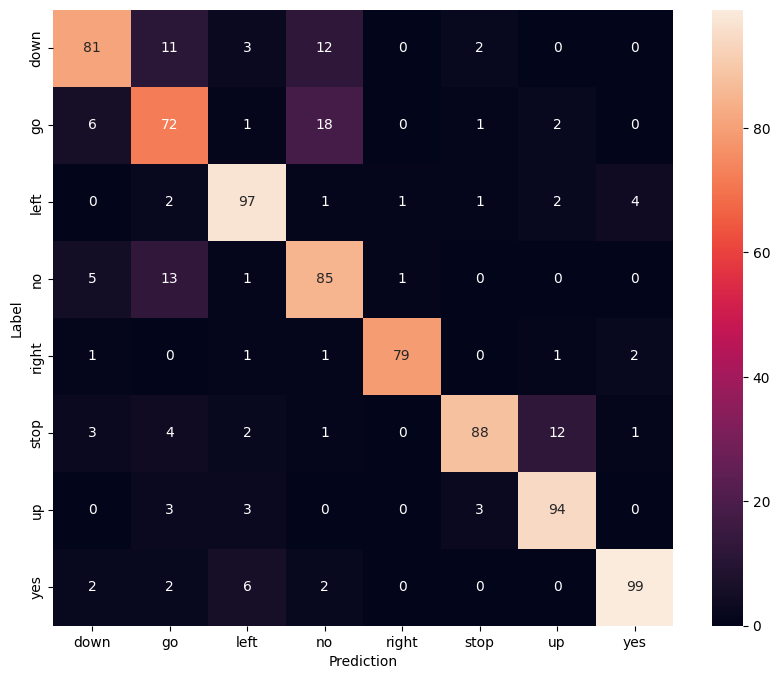

tf.Tensor(
[6 7 1 6 0 5 2 0 2 2 1 1 3 6 4 0 0 2 2 4 3 5 4 3 3 3 2 2 7 4 3 4 1 1 4 7 6
 4 1 6 2 7 1 6 0 1 2 0 3 1 4 3 2 5 1 3 5 3 2 7 3 4 3 0 0 1 3 4 7 1 5 7 6 1
 4 5 7 2 5 4 3 6 0 6 2 3 6 1 5 5 5 1 7 3 5 1 3 4 7 0 5 0 1 7 4 2 7 3 6 3 6
 5 1 3 5 6 2 2 5 4 6 6 3 7 6 2 3 4 3 6 4 5 0 1 1 5 1 2 3 6 3 7 7 1 5 2 7 7
 0 3 0 5 0 5 1 7 7 0 2 2 1 1 3 2 2 1 1 3 6 5 7 0 5 1 7 6 4 0 7 3 3 7 1 0 2
 7 1 3 4 7 6 6 7 6 5 6 5 1 2 6 7 2 7 4 3 1 6 0 4 4 1 7 1 7 5 5 1 7 1 2 2 0
 1 0 3 3 5 3 4 1 6 5 6 3 6 6 0 1 1 7 4 7 3 2 5 7 5 7 7 1 4 7 2 4 3 7 1 3 4
 6 7 7 5 4 7 2 3 2 7 2 0 7 2 2 1 2 4 7 1 1 4 1 0 6 0 2 7 7 2 7 0 0 2 5 4 3
 3 5 6 5 0 7 0 1 1 1 7 4 7 7 3 1 6 0 7 2 2 0 1 3 3 0 3 3 3 2 6 3 1 3 4 6 5
 7 4 6 2 4 6 2 1 2 4 2 1 3 6 4 2 7 2 2 6 3 5 0 5 3 0 6 7 7 4 5 2 2 7 0 7 1
 7 4 2 2 7 4 1 0 1 4 0 1 5 4 1 0 2 3 1 4 0 6 3 0 0 0 0 1 6 1 1 2 5 3 5 3 1
 4 6 4 0 4 3 6 1 0 5 7 7 0 6 1 5 5 7 1 1 5 0 6 0 2 0 0 6 5 6 3 3 3 0 7 6 0
 3 7 1 5 6 6 1 1 7 3 3 6 0 6 5 1 0 3 6 4 1 7 5 3 0 2 3 3 5 3 5 1 3 2 5 0 3
 3 0 2 6 1 1 4

In [18]:
y_pred = model.predict(test_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()
print(y_pred) #看不同词语的识别准确度

In [19]:
print(type(model))

<class 'tf_keras.src.engine.functional.Functional'>


In [20]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

# Compute end step to finish pruning after 2 epochs.
batch_size = 128
epochs = 10
validation_split = 0.1 # 10% of training set will be used for validation set. 

# 获取数据集中的样本数量
num_total = train_ds.cardinality().numpy()

# 计算用于训练的实际样本数
num_images = num_total * (1 - validation_split)
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs


# Define model for pruning.
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50,
                                                               final_sparsity=0.80,
                                                               begin_step=0,
                                                               end_step=end_step)
}#剪枝比例为0.8 从0.5开始一点一点到0.8

model_for_pruning = prune_low_magnitude(prunable_model, **pruning_params)

input_tensor = layers.Input(shape=input_shape)
x = preprocessing_model(input_tensor)
output_tensor = model_for_pruning(x)
model_for_pruning = keras.Model(inputs=input_tensor, outputs=output_tensor)

# `prune_low_magnitude` requires a recompile.
model_for_pruning.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_for_pruning.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 124, 129, 1)]     0         
                                                                 
 sequential (Sequential)     (None, 32, 32, 1)         3         
                                                                 
 sequential_1 (Sequential)   (None, 8)                 411524    
                                                                 
Total params: 411527 (1.57 MB)
Trainable params: 205800 (803.91 KB)
Non-trainable params: 205727 (803.66 KB)
_________________________________________________________________


In [21]:
logdir = tempfile.mkdtemp()

callbacks = [
  tfmot.sparsity.keras.UpdatePruningStep(),
  tfmot.sparsity.keras.PruningSummaries(log_dir=logdir),
]
  
model_for_pruning.fit(train_spectrogram_ds, 
                  batch_size=batch_size, epochs=epochs, validation_data=val_spectrogram_ds,
                  callbacks=callbacks)#剪枝训练（微调）

Epoch 1/10
100/100 [==============================] - 6s 25ms/step - loss: 0.4352 - accuracy: 0.8330 - val_loss: 0.4678 - val_accuracy: 0.8451
Epoch 2/10
100/100 [==============================] - 2s 22ms/step - loss: 0.4323 - accuracy: 0.8319 - val_loss: 0.4434 - val_accuracy: 0.8581
Epoch 3/10
100/100 [==============================] - 2s 22ms/step - loss: 0.4044 - accuracy: 0.8459 - val_loss: 0.4415 - val_accuracy: 0.8581
Epoch 4/10
100/100 [==============================] - 2s 22ms/step - loss: 0.4114 - accuracy: 0.8388 - val_loss: 0.4356 - val_accuracy: 0.8581
Epoch 5/10
100/100 [==============================] - 2s 22ms/step - loss: 0.4026 - accuracy: 0.8472 - val_loss: 0.4244 - val_accuracy: 0.8685
Epoch 6/10
100/100 [==============================] - 2s 23ms/step - loss: 0.3857 - accuracy: 0.8509 - val_loss: 0.4373 - val_accuracy: 0.8672
Epoch 7/10
100/100 [==============================] - 2s 22ms/step - loss: 0.3869 - accuracy: 0.8506 - val_loss: 0.4342 - val_accuracy: 0.8607

In [22]:
_, model_for_pruning_accuracy = model_for_pruning.evaluate(
   test_spectrogram_ds, verbose=0)
print('Pruned test accuracy:', model_for_pruning_accuracy)
print('Baseline test accuracy:', baseline_model_accuracy) #精准度对比

Pruned test accuracy: 0.8341346383094788
Baseline test accuracy: 0.8353365659713745


In [23]:
model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

pruned_keras_file = r'E:\python_1\tensor\pxb.keras'  # 使用原始字符串避免转义
keras.models.save_model(model_for_export, pruned_keras_file)
print('Saved pruned Keras model to:', pruned_keras_file)

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
pruned_tflite_model = converter.convert()

pruned_tflite_file = r'E:\python_1\tensor\pxb.tflite'  # 使用原始字符串避免转义

with open(pruned_tflite_file, 'wb') as f:
  f.write(pruned_tflite_model)

print('Saved pruned TFLite model to:', pruned_tflite_file)

Saved pruned Keras model to: E:\python_1\tensor\pxb.keras
INFO:tensorflow:Assets written to: C:\Users\13125\AppData\Local\Temp\tmpqa2wlevk\assets


INFO:tensorflow:Assets written to: C:\Users\13125\AppData\Local\Temp\tmpqa2wlevk\assets


Saved pruned TFLite model to: E:\python_1\tensor\pxb.tflite


In [24]:
def get_gzipped_model_size(file):
  # Returns size of gzipped model, in bytes.
  import os
  import zipfile

  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)

In [25]:
print("Size of gzipped baseline Keras model: %.2f bytes" % (get_gzipped_model_size(keras_file)))
print("Size of gzipped pruned Keras model: %.2f bytes" % (get_gzipped_model_size(pruned_keras_file)))
print("Size of gzipped pruned TFlite model: %.2f bytes" % (get_gzipped_model_size(pruned_tflite_file)))

Size of gzipped baseline Keras model: 2315536.00 bytes
Size of gzipped pruned Keras model: 769977.00 bytes
Size of gzipped pruned TFlite model: 766126.00 bytes


In [26]:
quantize_model = tfmot.quantization.keras.quantize_model

# q_aware stands for for quantization aware.
q_aware_model = quantize_model(prunable_model)

input_tensor = layers.Input(shape=input_shape)
x = preprocessing_model(input_tensor)
output_tensor = q_aware_model(x)
q_aware_model = keras.Model(inputs=input_tensor, outputs=output_tensor)

# `quantize_model` requires a recompile.
q_aware_model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

q_aware_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 124, 129, 1)]     0         
                                                                 
 sequential (Sequential)     (None, 32, 32, 1)         3         
                                                                 
 sequential_1 (Sequential)   (None, 8)                 205919    
                                                                 
Total params: 205922 (804.39 KB)
Trainable params: 205800 (803.91 KB)
Non-trainable params: 122 (492.00 Byte)
_________________________________________________________________


In [27]:
q_aware_model.fit(train_spectrogram_ds, 
                  batch_size=batch_size, epochs=epochs, validation_data=val_spectrogram_ds,
                  callbacks=callbacks) #量化感知训练

Epoch 1/10
100/100 [==============================] - 4s 30ms/step - loss: 0.7890 - accuracy: 0.6941 - val_loss: 0.6011 - val_accuracy: 0.8060
Epoch 2/10
100/100 [==============================] - 4s 36ms/step - loss: 0.6680 - accuracy: 0.7425 - val_loss: 0.5445 - val_accuracy: 0.8203
Epoch 3/10
100/100 [==============================] - 3s 27ms/step - loss: 0.5730 - accuracy: 0.7788 - val_loss: 0.5200 - val_accuracy: 0.8333
Epoch 4/10
100/100 [==============================] - 3s 28ms/step - loss: 0.5531 - accuracy: 0.7914 - val_loss: 0.5364 - val_accuracy: 0.8177
Epoch 5/10
100/100 [==============================] - 3s 28ms/step - loss: 0.4983 - accuracy: 0.8069 - val_loss: 0.5196 - val_accuracy: 0.8294
Epoch 6/10
100/100 [==============================] - 3s 27ms/step - loss: 0.4866 - accuracy: 0.8142 - val_loss: 0.4967 - val_accuracy: 0.8255
Epoch 7/10
100/100 [==============================] - 3s 27ms/step - loss: 0.4778 - accuracy: 0.8147 - val_loss: 0.5118 - val_accuracy: 0.8216

In [28]:
model_for_export = tfmot.sparsity.keras.strip_pruning(q_aware_model)
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_and_pruned_tflite_model = converter.convert()

quantized_and_pruned_tflite_file = r'E:\python_1\tensor\pxb11.tflite'

with open(quantized_and_pruned_tflite_file, 'wb') as f:
  f.write(quantized_and_pruned_tflite_model)

print('Saved quantized and pruned TFLite model to:', quantized_and_pruned_tflite_file)

print("Size of gzipped baseline Keras model: %.2f bytes" % (get_gzipped_model_size(keras_file)))
print("Size of gzipped pruned and quantized TFlite model: %.2f bytes" % (get_gzipped_model_size(quantized_and_pruned_tflite_file)))#训练后量化

INFO:tensorflow:Assets written to: C:\Users\13125\AppData\Local\Temp\tmp7v4lrvko\assets


INFO:tensorflow:Assets written to: C:\Users\13125\AppData\Local\Temp\tmp7v4lrvko\assets
E:\Tensorflow\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved quantized and pruned TFLite model to: E:\python_1\tensor\pxb11.tflite
Size of gzipped baseline Keras model: 2315536.00 bytes
Size of gzipped pruned and quantized TFlite model: 173847.00 bytes


In [29]:
print("Model type:", type(quantized_and_pruned_tflite_model))  # 应为 <class 'bytes'>
print("Model size:", len(quantized_and_pruned_tflite_model))   # 应为正数

Model type: <class 'bytes'>
Model size: 212496


In [30]:
import numpy as np

def evaluate_model(interpreter, test_ds):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    
    # 获取模型期望的输入形状
    input_shape = interpreter.get_input_details()[0]["shape"]
    print(f"Model expects input shape: {input_shape}")
    
    prediction_digits = []
    true_labels = []
    
    for i, (spectrogram_batch, label_batch) in enumerate(test_ds):
        
        # 处理批次中的每个样本
        for j in range(spectrogram_batch.shape[0]):
            # 获取单个样本
            spectrogram = spectrogram_batch[j].numpy().astype(np.float32)
            label = label_batch[j].numpy()
            
            # 打印原始形状以调试
            if i == 0 and j == 0:  # 只打印第一个样本的形状
                print(f"Original spectrogram shape: {spectrogram.shape}")
            
            # 确保形状正确 [1, 124, 129, 1]
            if len(spectrogram.shape) == 2:  # [124, 129]
                spectrogram = np.expand_dims(spectrogram, axis=(0, -1))  # 添加批次和通道维度
            elif len(spectrogram.shape) == 3:  # [124, 129, 1]
                spectrogram = np.expand_dims(spectrogram, axis=0)  # 添加批次维度
            
            # 再次检查形状
            if i == 0 and j == 0:
                print(f"Adjusted spectrogram shape: {spectrogram.shape}")
            
            # 设置输入并运行推理
            interpreter.set_tensor(input_index, spectrogram)
            interpreter.invoke()
            
            # 获取输出
            output = interpreter.get_tensor(output_index)
            digit = np.argmax(output[0])
            
            prediction_digits.append(digit)
            true_labels.append(label)
    
    print(f'Total samples evaluated: {len(prediction_digits)}')
    prediction_digits = np.array(prediction_digits)
    true_labels = np.array(true_labels)
    
    # 计算准确率
    accuracy = (prediction_digits == true_labels).mean()
    return accuracy #测试集上验证精准度

In [31]:
interpreter = tf.lite.Interpreter(model_content=quantized_and_pruned_tflite_model)
interpreter.allocate_tensors()

test_accuracy = evaluate_model(interpreter,test_spectrogram_ds)

print('Pruned and quantized TFLite test_accuracy:', test_accuracy)
print('Pruned TF test accuracy:', model_for_pruning_accuracy)

Model expects input shape: [  1 124 129   1]
Original spectrogram shape: (124, 129, 1)
Adjusted spectrogram shape: (1, 124, 129, 1)


E:\Tensorflow\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Total samples evaluated: 832
Pruned and quantized TFLite test_accuracy: 0.8185096153846154
Pruned TF test accuracy: 0.8341346383094788
